In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

original = pd.read_csv('c:\python\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]
original = original.reset_index(drop = True)
original = original.drop(original[original['신고중량'] == 0].index)

original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

date_index = original['연도주차'].unique()

use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_40주차
194   0.273
195   0.276
196   0.277
197   0.278
198   0.281
199   0.284
200   0.285
201   0.285
202   0.287
203   0.287
204   0.302
205   0.307
206   0.308
207   0.310
208   0.304
209   0.304
210   0.306
211   0.310
212   0.312
213   0.320
214   0.329
215   0.332
216   0.341
217   0.347
218   0.351
219   0.360
220   0.366
221   0.367
222   0.368
223   0.368
224   0.365
225   0.365
226   0.368
227   0.371
228   0.373
229   0.375
230   0.372
231   0.387
232   0.398
233   0.402
234   0.417
235   0.433
236   0.446
237   0.464
238   0.470
239   0.479
240   0.501
241   0.500
242   0.498

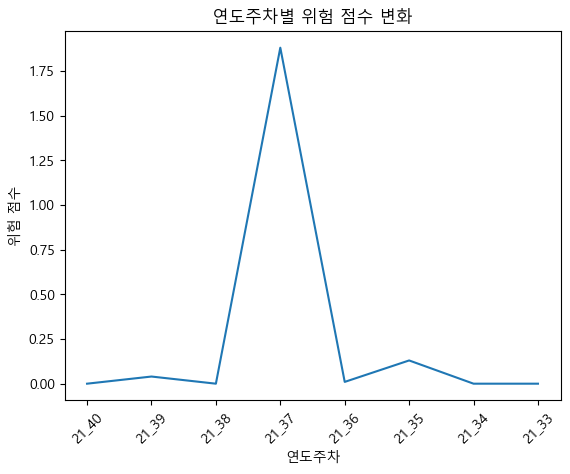

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_30주차
79    232.394
80    239.664
81    243.658
82    241.069
83    270.627
84    241.770
85    275.102
86    270.882
87    274.426
88    273.856
89    243.639
90    240.823
91    231.794
92    251.146
93    277.998
94    272.614
95    292.676
96    274.076
97    287.220
98    326.250
99    296.285
100   286.282
101   246.525
102   210.616
103   234.737
104   244.200
105   254.369
106   261.244
107   261.333
108   265.613
109   314.574
110   282.201
111   294.642
112   300.052
113   298.393
114   320.318
115   326.430
116   290.426
117   265.435
118   246.845
119   263.072
120   289.953
121   264.3

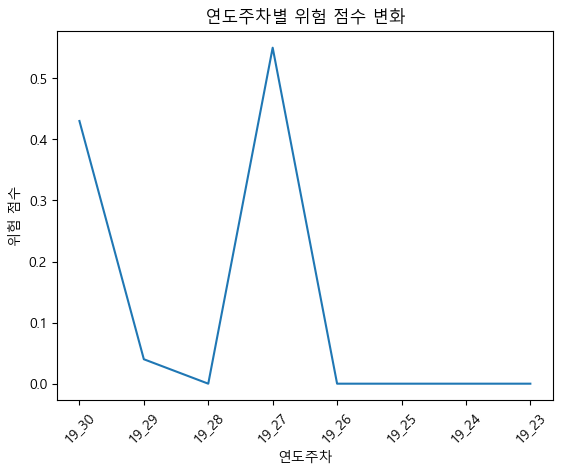

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
21_14주차
168   1.168
169   1.273
170   1.278
171   1.296
172   1.307
173   1.282
174   1.246
175   1.225
176   1.222
177   1.217
178   1.240
179   1.241
180   1.239
181   1.256
182   1.291
183   1.279
184   1.276
185   1.256
186   1.236
187   1.272
188   1.268
189   1.283
190   1.301
191   1.275
192   1.316
193   1.192
194   1.178
195   1.191
196   1.172
197   1.283
198   1.298
199   1.299
200   1.309
201   1.323
202   1.315
203   1.257
204   1.252
205   1.248
206   1.271
207   1.309
208   1.326
209   1.275
210   1.288
211   1.294
212   1.303
213   1.369
214   1.390
215   1.353
216   1.318
217   1.269
218   1.271

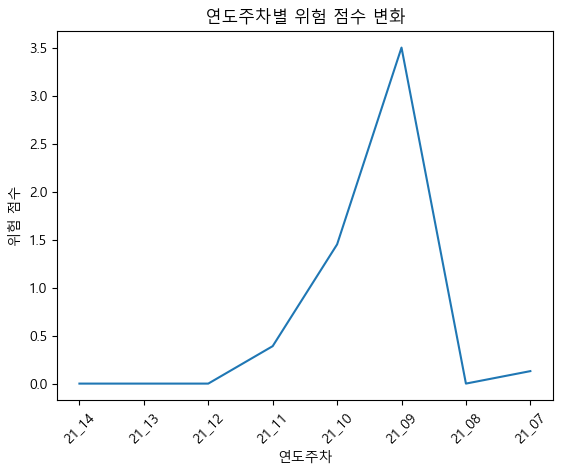

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_45주차
199   1.529
200   1.524
201   1.523
202   1.519
203   1.540
204   1.577
205   1.619
206   1.670
207   1.729
208   1.849
209   1.911
210   1.981
211   2.053
212   2.281
213   2.331
214   2.448
215   2.445
216   2.461
217   2.481
218   2.490
219   2.479
220   2.496
221   2.483
222   2.499
223   2.559
224   2.567
225   2.589
226   2.603
227   2.582
228   2.566
229   2.541
230   2.551
231   2.547
232   2.577
233   2.583
234   2.612
235   2.658
236   2.695
237   2.774
238   2.806
239   2.897
240   3.019
241   3.186
242   3.614
243   3.963
244   4.185
245   4.269
246   4.371
247   4.494
248   4.554

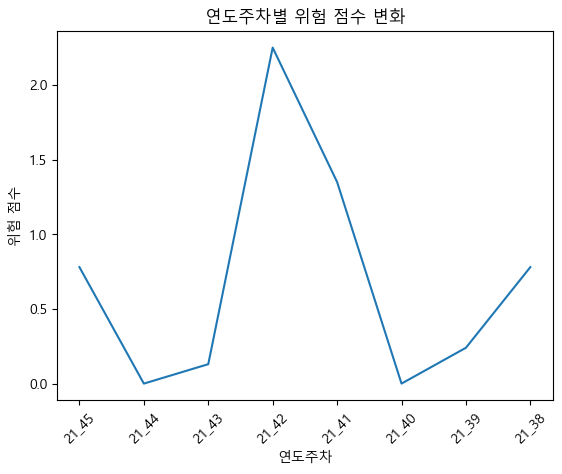

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_51주차
205   0.103
206   0.107
207   0.107
208   0.110
209   0.113
210   0.116
211   0.116
212   0.126
213   0.122
214   0.119
215   0.127
216   0.123
217   0.136
218   0.134
219   0.131
220   0.127
221   0.116
222   0.115
223   0.130
224   0.130
225   0.130
226   0.131
227   0.120
228   0.128
229   0.134
230   0.134
231   0.137
232   0.138
233   0.134
234   0.133
235   0.151
236   0.167
237   0.174
238   0.184
239   0.187
240   0.196
241   0.192
242   0.191
243   0.190
244   0.186
245   0.187
246   0.210
247   0.248
248   0.243
249   0.252
250   0.255
251   0.256
252   0.270

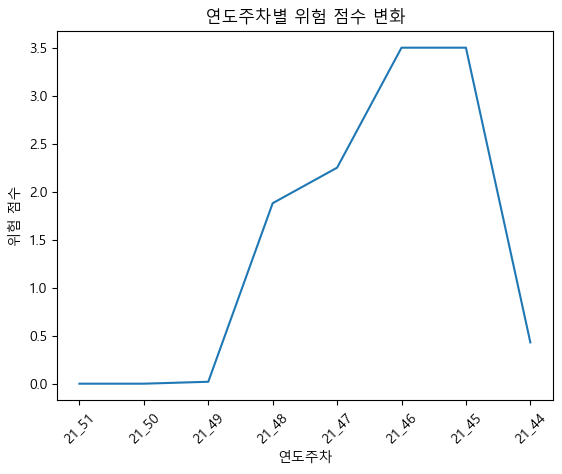

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_51주차
205   2.941
206   3.446
207   3.332
208   3.499
209   3.310
210   2.799
211   2.863
212   2.831
213   2.821
214   2.890
215   2.824
216   2.865
217   2.883
218   2.876
219   2.908
220   2.917
221   2.906
222   2.891
223   2.912
224   2.931
225   2.909
226   2.869
227   2.830
228   2.816
229   2.820
230   2.829
231   2.819
232   2.800
233   2.900
234   2.929
235   2.988
236   3.028
237   3.024
238   3.037
239   3.074
240   3.121
241   3.081
242   3.062
243   3.018
244   3.040
245   3.063
246   3.375
247   3.465
248   4.208
249   4.980
250   5.144
251   5.250
252   5.232
253   5.226
254   5.269
255   5.266

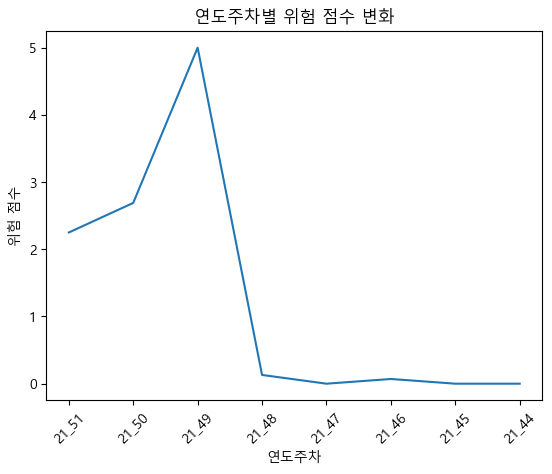

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
22_02주차
209   0.938
210   0.929
211   0.964
212   0.970
213   1.038
214   1.039
215   1.047
216   1.055
217   1.030
218   1.030
219   1.033
220   1.022
221   1.038
222   1.037
223   1.030
224   1.036
225   1.043
226   1.050
227   1.048
228   1.040
229   1.088
230   1.083
231   1.091
232   1.091
233   1.162
234   1.105
235   1.101
236   1.101
237   1.102
238   1.106
239   1.106
240   1.109
241   1.108
242   1.101
243   1.080
244   1.079
245   1.080
246   1.099
247   1.122
248   1.122
249   1.120
250   1.109
251   1.141
252   1.204
253   1.204
254   1.204
255   1.318
256   1.342
257   1.344
258   1.343

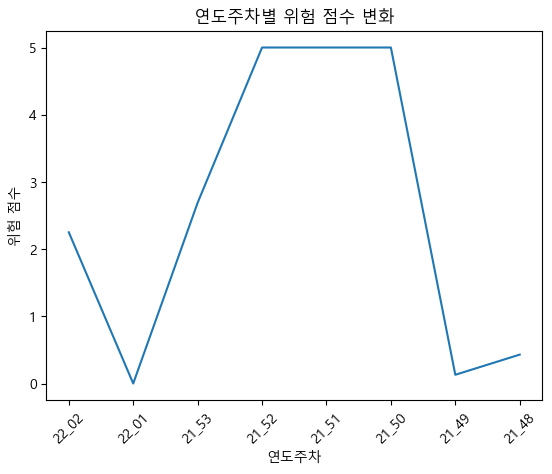

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
22_07주차
214   10.195
215   10.037
216   10.390
217   10.453
218   10.162
219    9.852
220    9.621
221    9.196
222    9.350
223    9.638
224   10.013
225    9.977
226   10.147
227   10.167
228    9.490
229    9.620
230    9.601
231    9.705
232   10.421
233   10.462
234   10.554
235   10.553
236   10.477
237   10.527
238   10.073
239   10.360
240   10.401
241   10.182
242   10.092
243    9.916
244    9.802
245   10.003
246   10.436
247   10.247
248    9.902
249    9.951
250   10.039
251    9.968
252   10.168
253    9.876
254    9.483
255    9.885
256   10.229
257   10.752
258   11.275
259   11.267
26

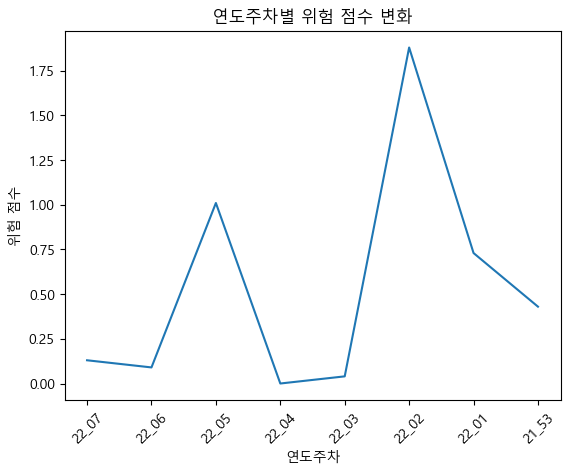

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
22_08주차
215    9.300
216    9.672
217    9.979
218   10.184
219   10.329
220   10.529
221   10.716
222   10.961
223   11.144
224   11.442
225   11.862
226   12.057
227   11.951
228   11.591
229   11.142
230   10.882
231   10.815
232   10.860
233   10.877
234   10.978
235   11.150
236   11.291
237   11.276
238   10.982
239   10.477
240    9.980
241    9.511
242    9.247
243    9.175
244    9.185
245    9.278
246    9.490
247    9.675
248    9.960
249   10.165
250   10.085
251    9.902
252    9.799
253    9.744
254    9.815
255   10.170
256   10.750
257   11.324
258   11.664
259   11.969
260   11.867
26

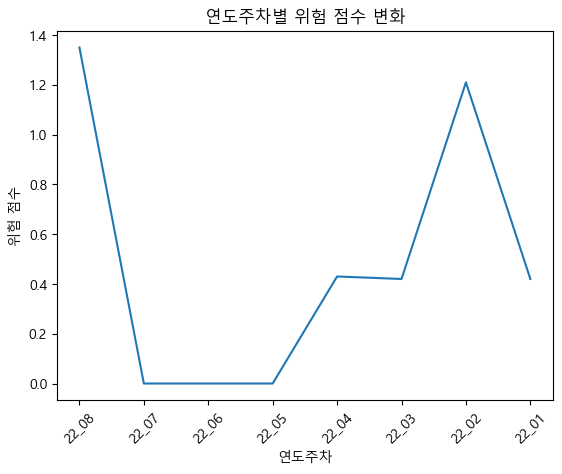

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
22_07주차
214   0.216
215   0.217
216   0.217
217   0.217
218   0.217
219   0.216
220   0.216
221   0.216
222   0.216
223   0.223
224   0.225
225   0.227
226   0.224
227   0.216
228   0.222
229   0.222
230   0.224
231   0.226
232   0.224
233   0.231
234   0.228
235   0.230
236   0.228
237   0.223
238   0.225
239   0.219
240   0.219
241   0.220
242   0.220
243   0.220
244   0.220
245   0.227
246   0.233
247   0.232
248   0.233
249   0.229
250   0.229
251   0.240
252   0.240
253   0.247
254   0.245
255   0.238
256   0.247
257   0.239
258   0.242
259   0.252
260   0.229
261   0.229
262   0.229
263   0.229

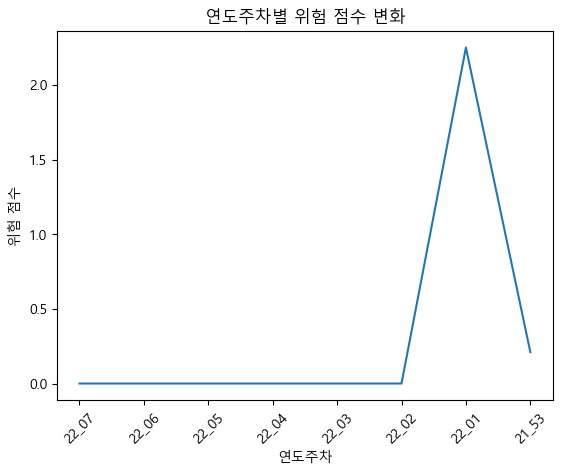

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
22_07주차
214   0.244
215   0.239
216   0.236
217   0.247
218   0.254
219   0.254
220   0.246
221   0.256
222   0.283
223   0.283
224   0.283
225   0.282
226   0.278
227   0.272
228   0.272
229   0.269
230   0.281
231   0.293
232   0.293
233   0.287
234   0.268
235   0.269
236   0.269
237   0.277
238   0.279
239   0.289
240   0.271
241   0.266
242   0.264
243   0.264
244   0.267
245   0.279
246   0.286
247   0.281
248   0.288
249   0.281
250   0.281
251   0.291
252   0.278
253   0.284
254   0.306
255   0.306
256   0.335
257   0.327
258   0.329
259   0.331
260   0.344
261   0.348
262   0.346
263   0.346

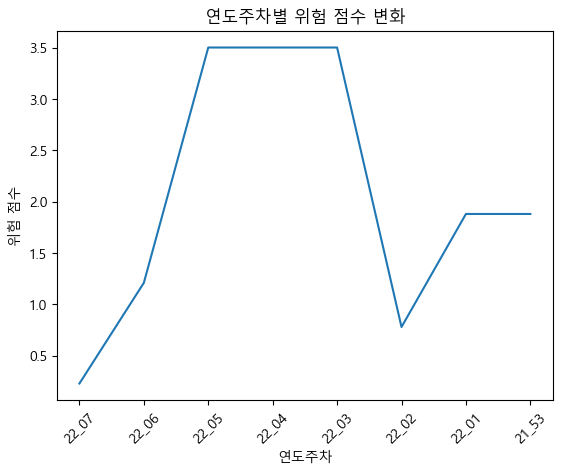

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
22_07주차
214   0.415
215   0.410
216   0.404
217   0.412
218   0.411
219   0.414
220   0.410
221   0.424
222   0.414
223   0.418
224   0.420
225   0.408
226   0.414
227   0.407
228   0.405
229   0.392
230   0.392
231   0.392
232   0.394
233   0.394
234   0.396
235   0.397
236   0.395
237   0.395
238   0.394
239   0.394
240   0.396
241   0.397
242   0.397
243   0.405
244   0.407
245   0.411
246   0.411
247   0.411
248   0.412
249   0.410
250   0.411
251   0.410
252   0.410
253   0.411
254   0.409
255   0.410
256   0.411
257   0.411
258   0.411
259   0.412
260   0.416
261   0.416
262   0.418
263   0.418
264   0.421

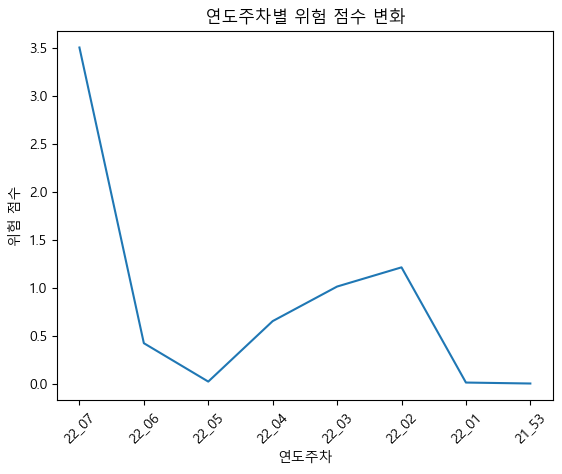

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
22_07주차
214   0.557
215   0.587
216   0.587
217   0.598
218   0.633
219   0.647
220   0.646
221   0.642
222   0.633
223   0.622
224   0.633
225   0.634
226   0.663
227   0.658
228   0.527
229   0.571
230   0.570
231   0.559
232   0.679
233   0.687
234   0.724
235   0.730
236   0.733
237   0.733
238   0.732
239   0.782
240   0.663
241   0.663
242   0.665
243   0.679
244   0.692
245   0.695
246   0.692
247   0.707
248   0.735
249   0.758
250   0.879
251   0.838
252   0.827
253   0.812
254   0.812
255   0.752
256   0.741
257   0.779
258   0.629
259   0.578
260   0.712
261   0.694
262   0.811

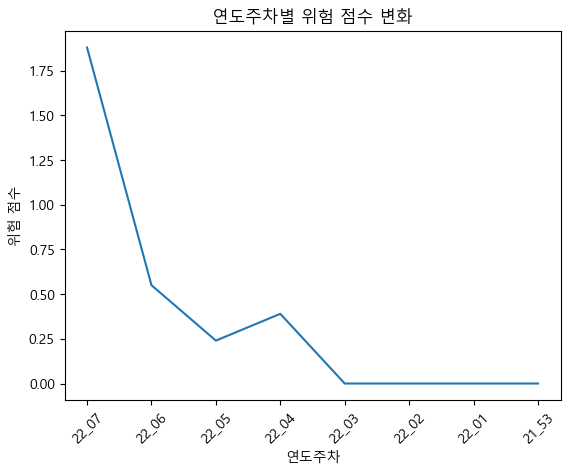

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
22_07주차
214   0.265
215   0.271
216   0.268
217   0.272
218   0.261
219   0.260
220   0.260
221   0.260
222   0.299
223   0.280
224   0.279
225   0.280
226   0.276
227   0.299
228   0.283
229   0.283
230   0.278
231   0.278
232   0.274
233   0.280
234   0.286
235   0.288
236   0.295
237   0.343
238   0.356
239   0.368
240   0.368
241   0.369
242   0.388
243   0.389
244   0.369
245   0.372
246   0.363
247   0.353
248   0.355
249   0.380
250   0.380
251   0.533
252   0.445
253   0.435
254   0.435
255   0.436
256   0.427
257   0.428
258   0.418
259   0.436
260   0.455
261   0.452
262   0.475

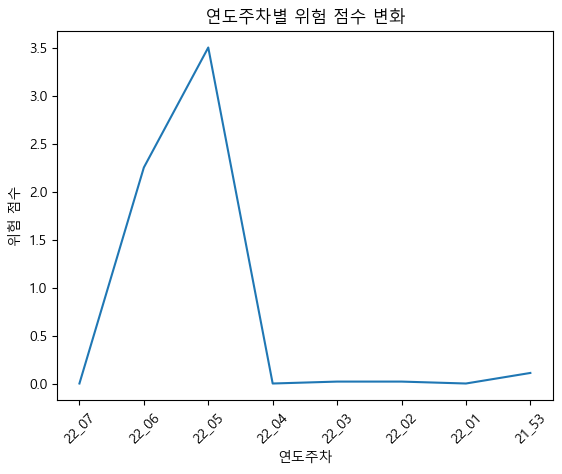

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
22_16주차
223   1.868
224   1.884
225   1.888
226   1.972
227   1.982
228   2.164
229   2.211
230   2.363
231   2.266
232   2.237
233   2.206
234   2.106
235   2.144
236   2.074
237   2.136
238   2.217
239   2.281
240   2.268
241   2.303
242   2.208
243   2.411
244   2.438
245   2.393
246   2.378
247   2.260
248   2.278
249   2.390
250   2.436
251   2.515
252   2.421
253   2.293
254   2.319
255   2.320
256   2.359
257   2.538
258   2.443
259   2.374
260   2.305
261   2.150
262   2.380
263   2.506
264   2.610
265   2.648
266   2.670
267   2.786
268   2.745
269   2.751
270   2.780
271   2.781
272   2.885
273   2.877

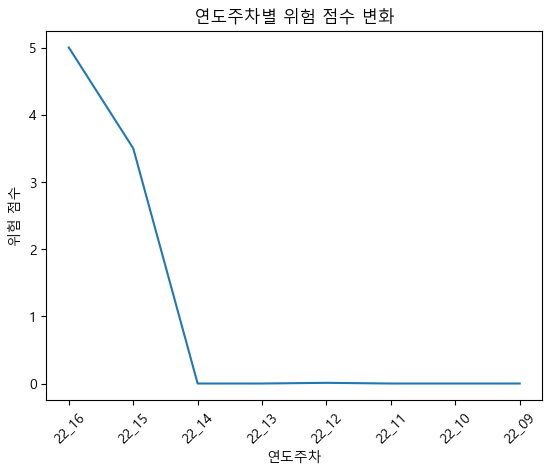

[np.float64(1.88), np.float64(0.55), np.float64(3.5), np.float64(2.25), np.float64(3.5), np.float64(5.0), np.float64(5.0), np.float64(1.88), np.float64(1.35), np.float64(2.25), np.float64(3.5), np.float64(3.5), np.float64(1.88), np.float64(3.5), np.float64(5.0)]
[54, 169, 82, 49, 45, 42, 39, 36, 30, 37, 33, 31, 31, 33, 22]


In [32]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        print(df_price_4w.iloc[p_eriod-l:-l]['단가'])
        ecdf = ECDF(df_price_4w.iloc[p_eriod-l:-l]['단가'])
        y=np.exp((ecdf(df_price_4w.iloc[-1-l]['단가'])*100 - 95)*np.log(5)/5)

        #=================== 신고중량 percertile 구하기 ====================
        
        ecdf = ECDF(df_price_4w['신고중량'].iloc[p_eriod-l:-l])
        if(ecdf(df_price_4w['신고중량'].iloc[-1-l])>0.5):
            x=np.exp((ecdf(df_price_4w['신고중량'].iloc[-1-l])*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-ecdf(df_price_4w['신고중량'].iloc[-1-l]))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y      
      
    if(z[j]>1.85):
        o[j] = 1 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model0(1)'] = o
collect.loc[15, 'Model0(1)'] = np.sum(o)
collect.loc[:14, 'Model0(2)'] = z
collect.loc[15, 'Model0(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[1]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[1]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[1]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


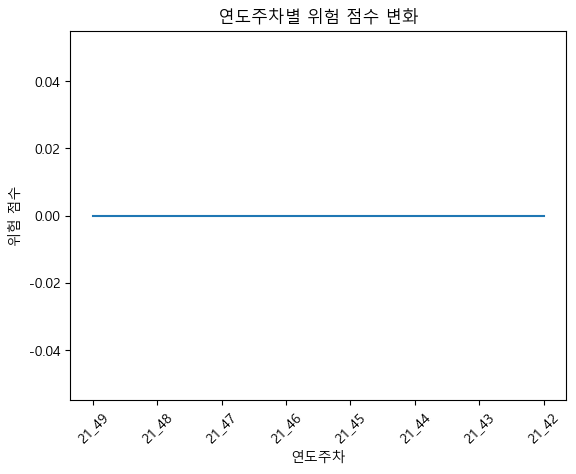

HS Code : 7326909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


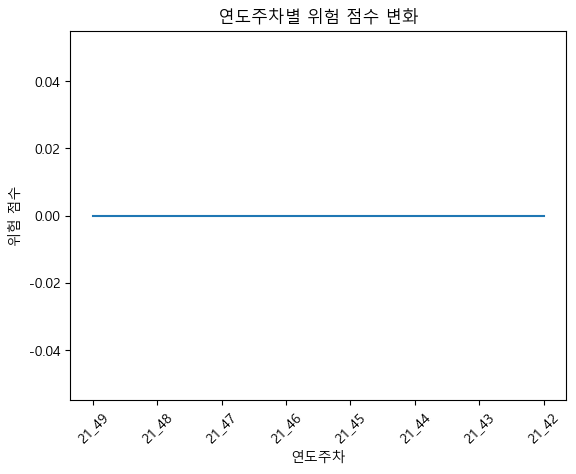

HS Code : 8708999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


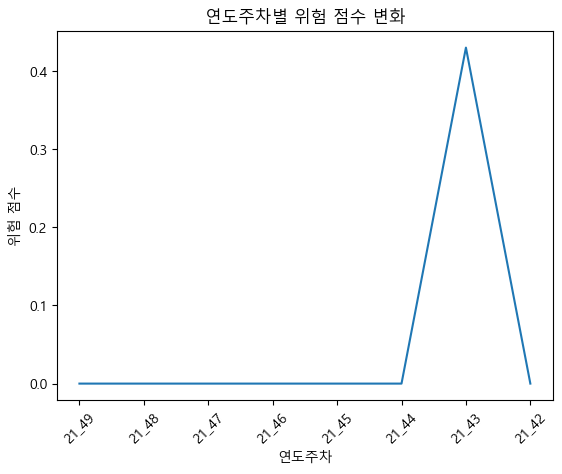

HS Code : 2106909099
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


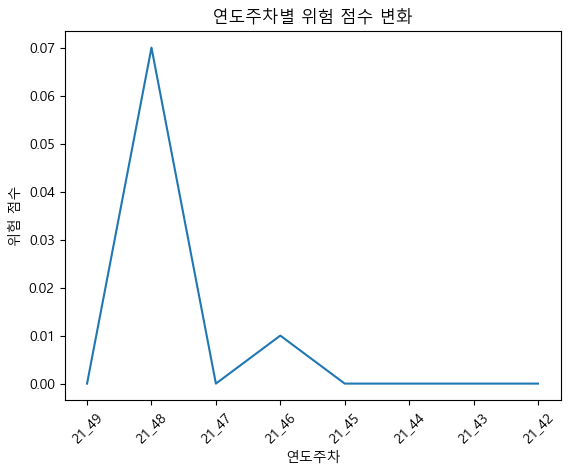

HS Code : 4911990000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


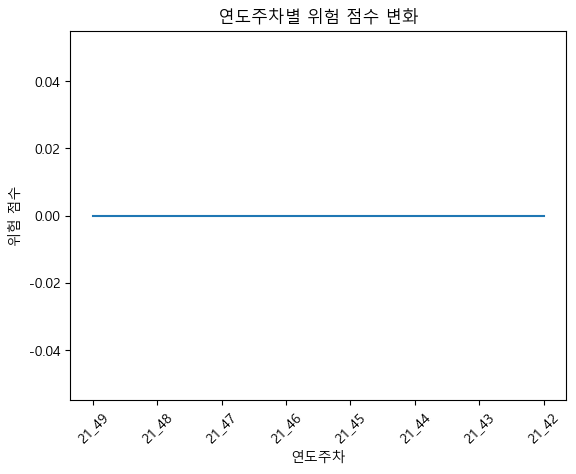

HS Code : 6403999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


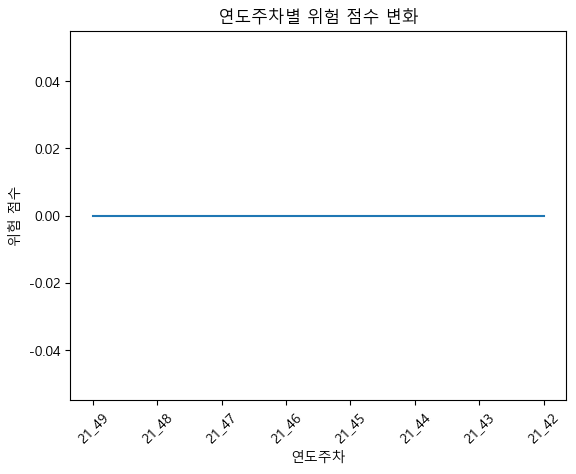

HS Code : 9031809099
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


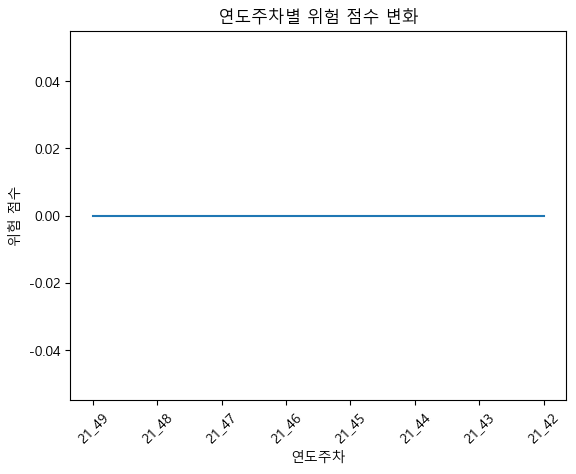

HS Code : 8542391000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


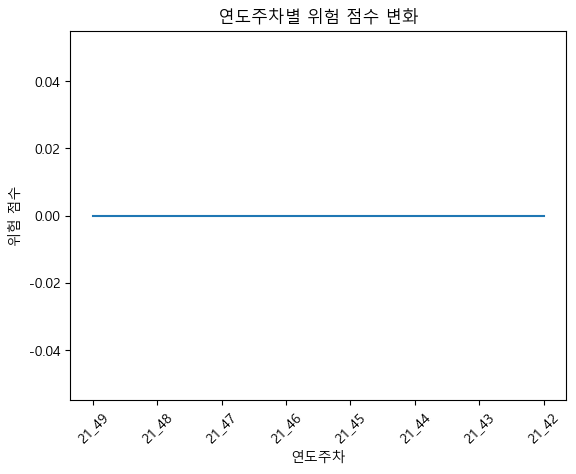

HS Code : 6109101000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


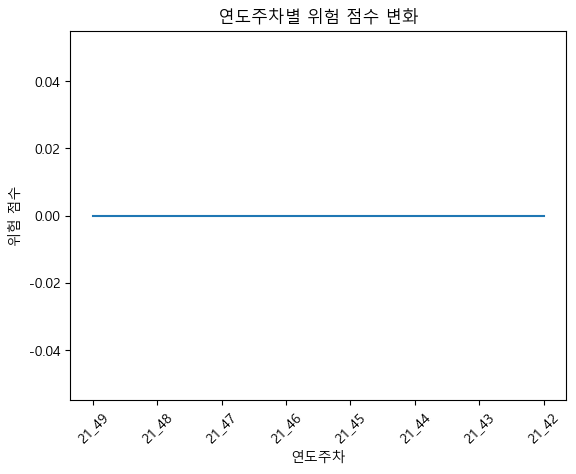

HS Code : 2934996000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


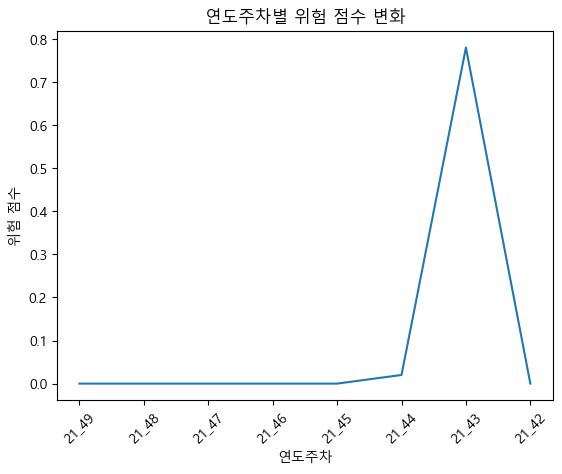

HS Code : 4016930000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


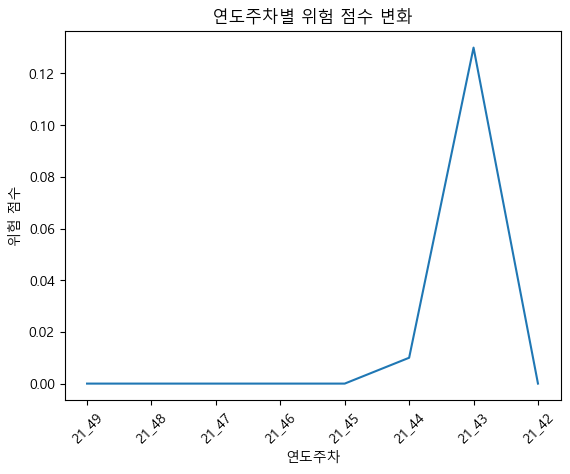

HS Code : 6110200000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


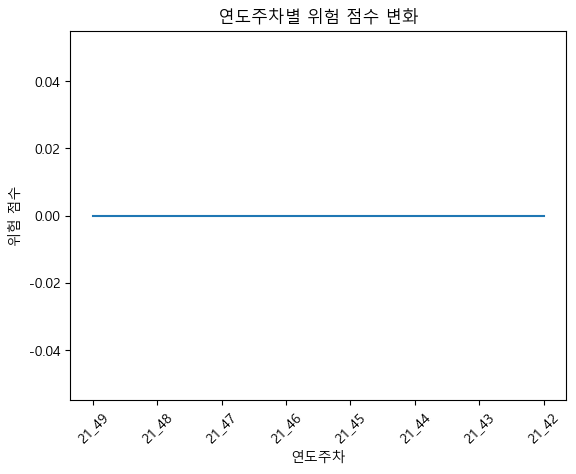

HS Code : 6211499000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


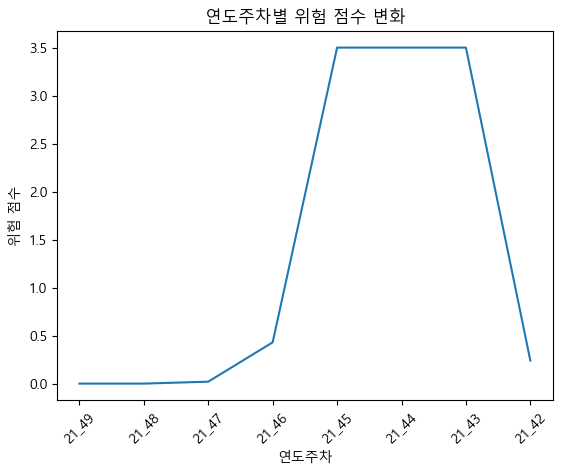

HS Code : 4202999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


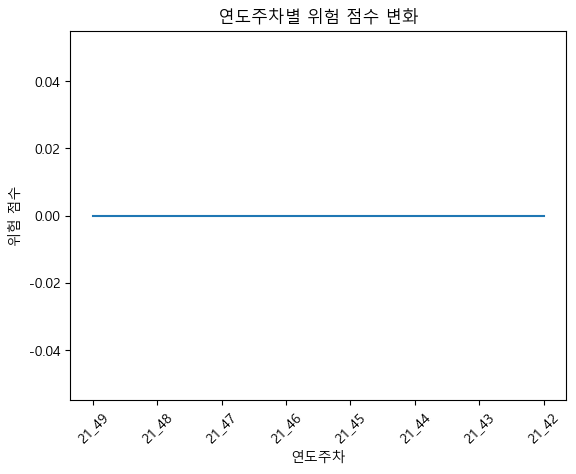

HS Code : 3304991000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


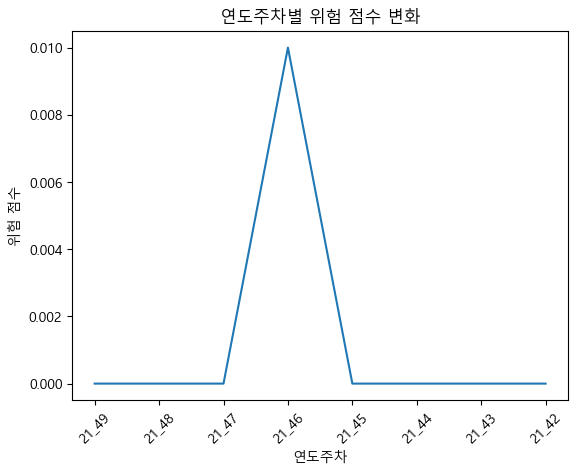

HS Code : 8544429090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


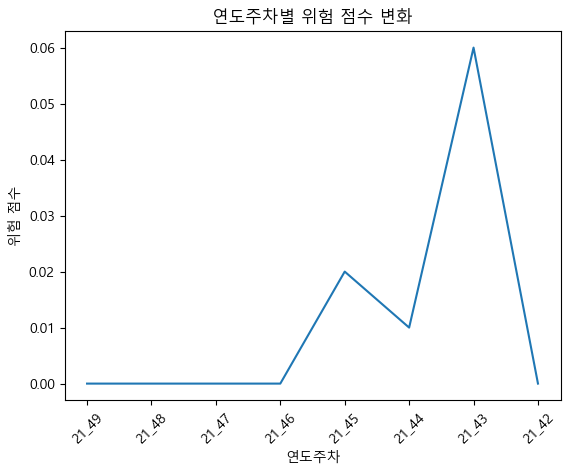

HS Code : 8481801090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


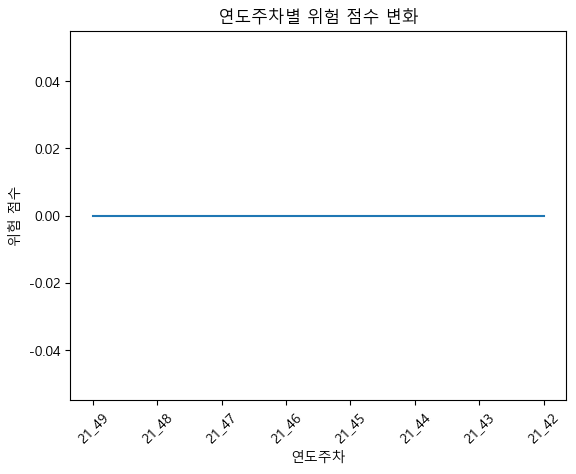

HS Code : 3304999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


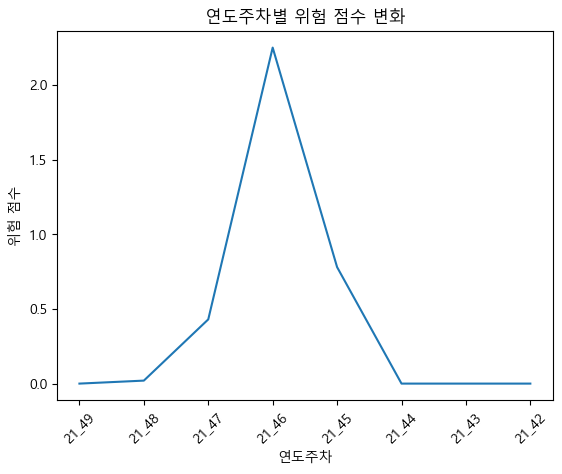

HS Code : 8543709090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


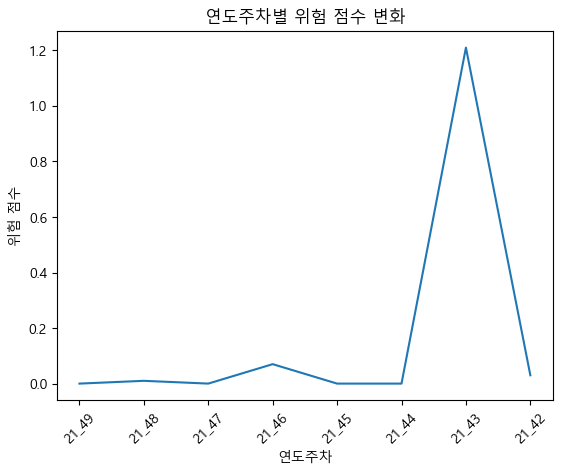

HS Code : 6404199000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


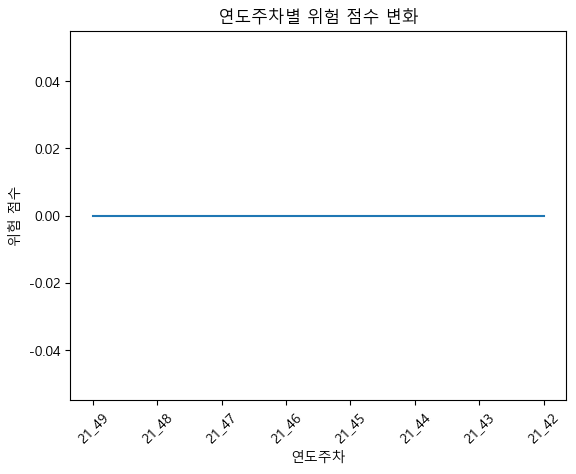

HS Code : 3004909900
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


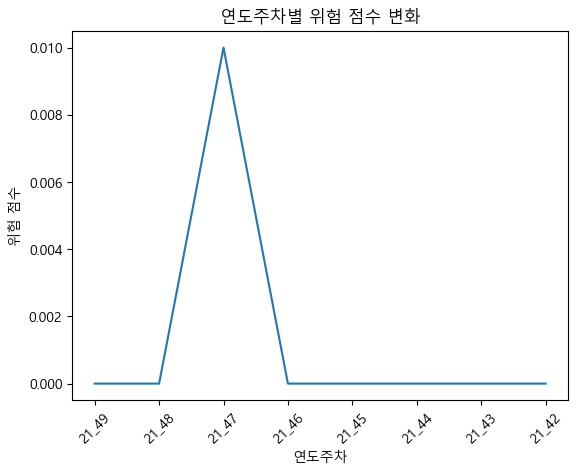

HS Code : 8542311000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


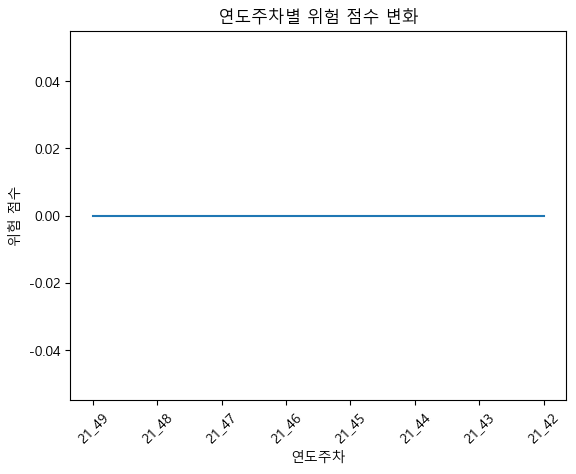

HS Code : 4901999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


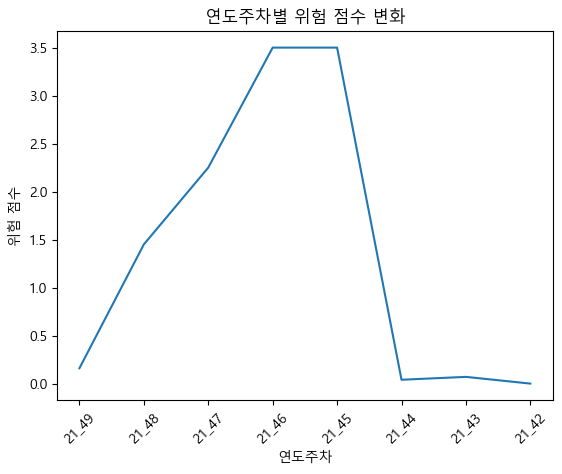

HS Code : 8473309090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


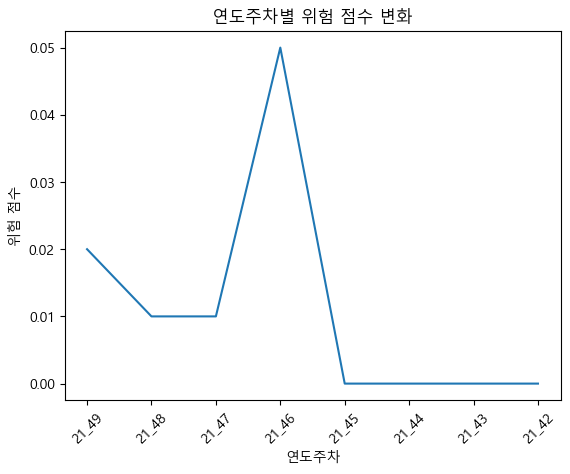

HS Code : 6307909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


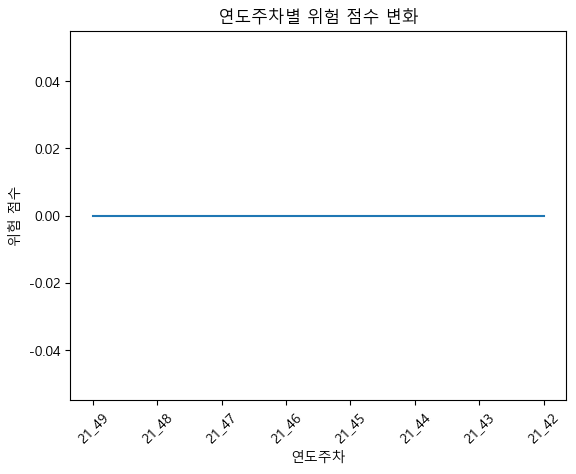

HS Code : 4202211090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


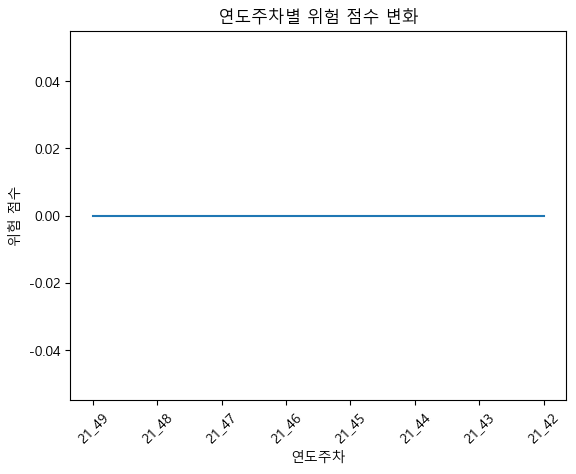

HS Code : 8536509090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


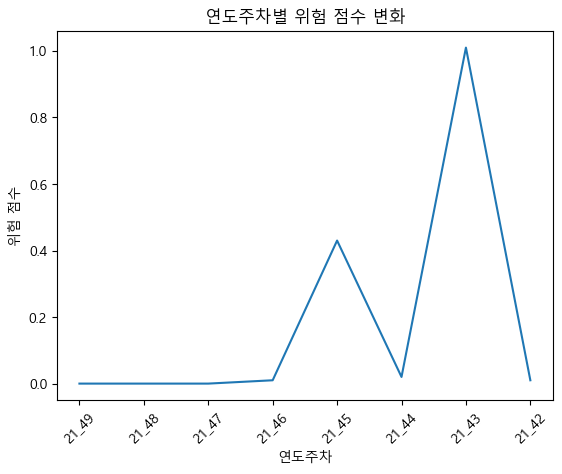

HS Code : 8538909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


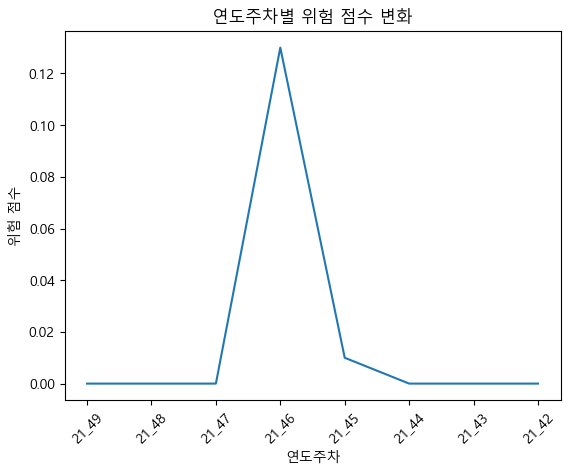

HS Code : 8479909090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


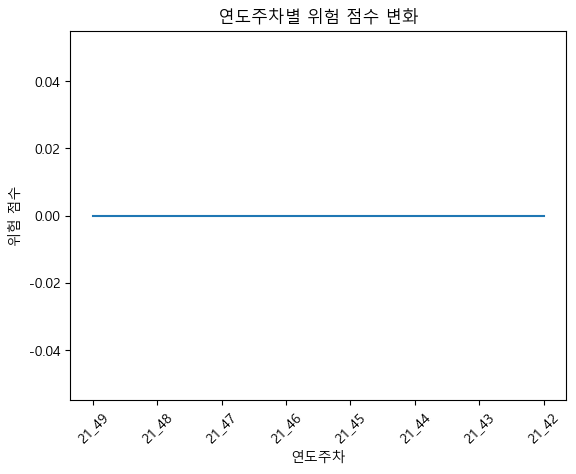

HS Code : 8504409099
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


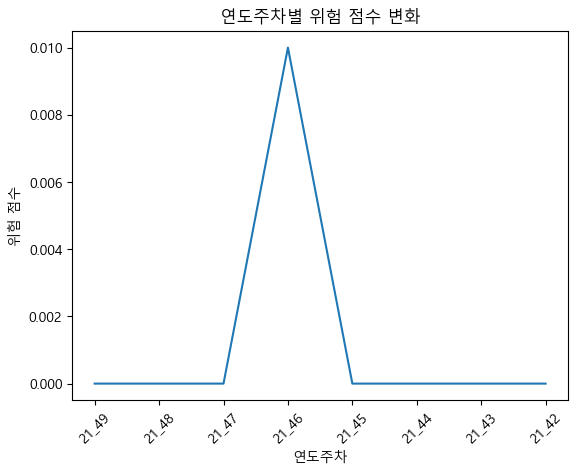

HS Code : 6110909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


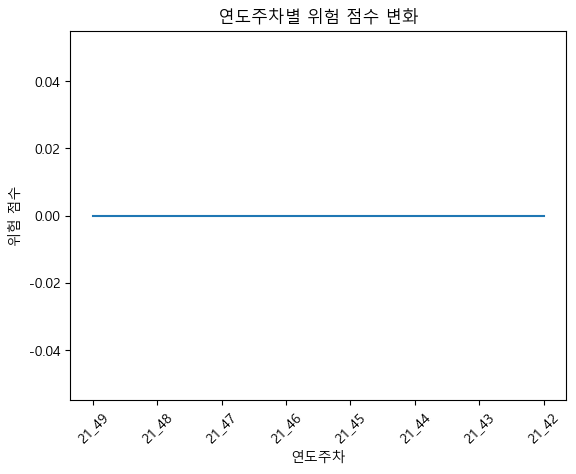

HS Code : 3923100000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


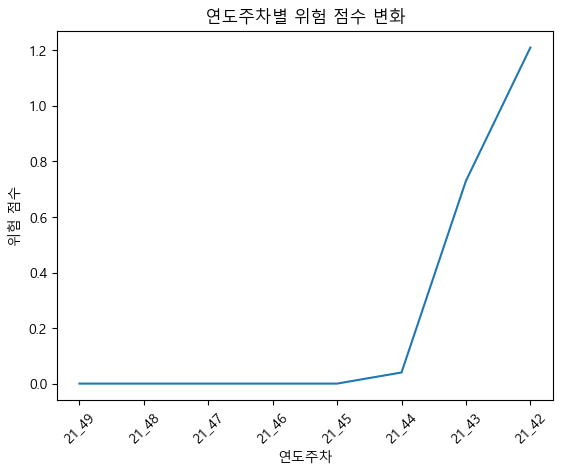

HS Code : 8544422090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


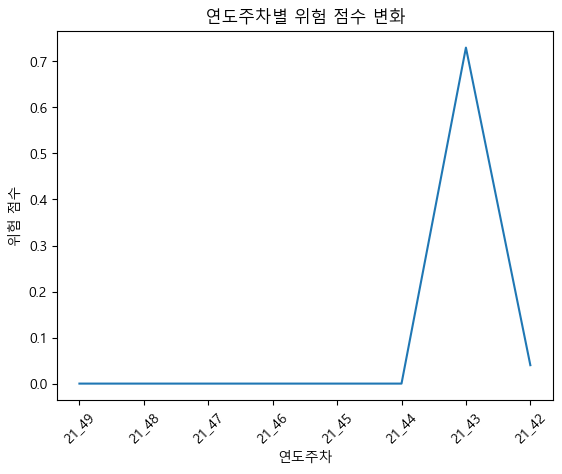

HS Code : 8537109000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


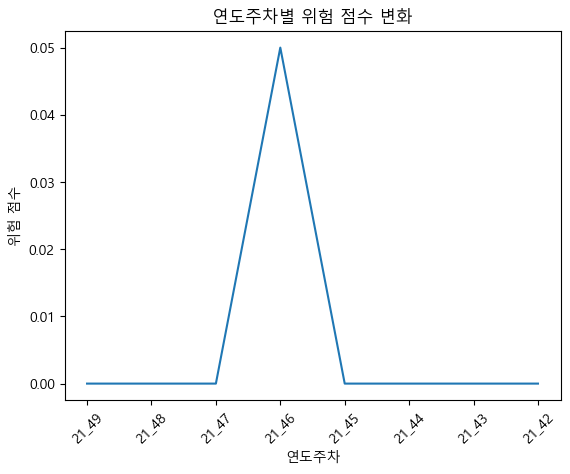

HS Code : 8536699000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


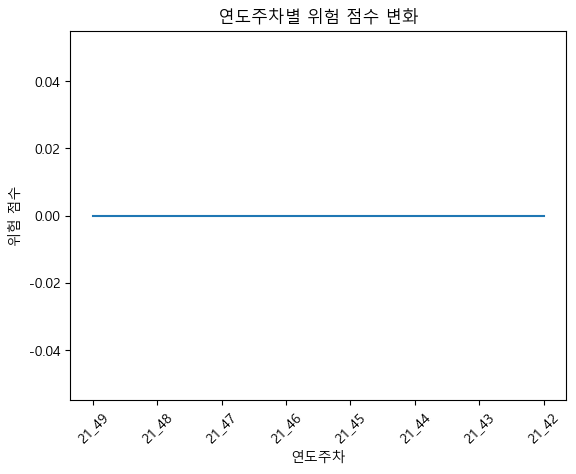

HS Code : 3102109000
21_14주차
21_13주차
21_12주차
21_11주차
21_10주차
21_09주차
21_08주차
21_07주차


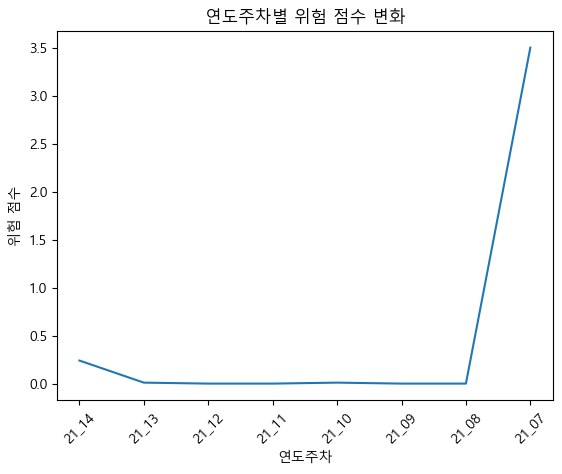

HS Code : 3707901010
19_04주차
19_03주차
19_02주차
19_01주차
18_52주차
18_51주차
18_50주차
18_49주차


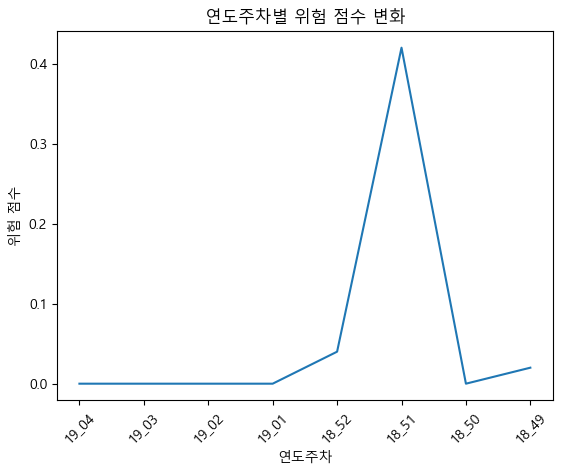

HS Code : 4407191000
20_41주차
20_40주차
20_39주차
20_38주차
20_37주차
20_36주차
20_35주차
20_34주차


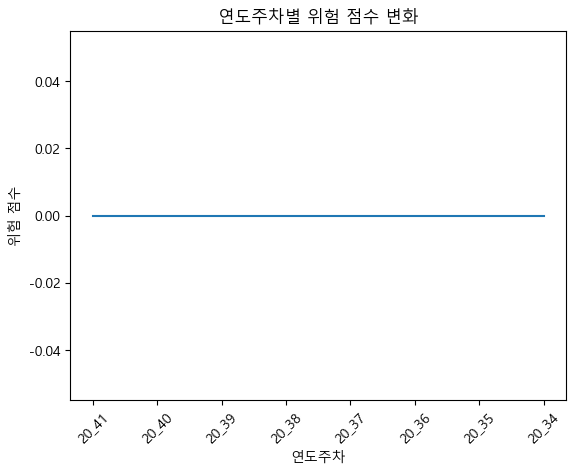

HS Code : 8111000000
21_19주차
21_18주차
21_17주차
21_16주차
21_15주차
21_14주차
21_13주차
21_12주차


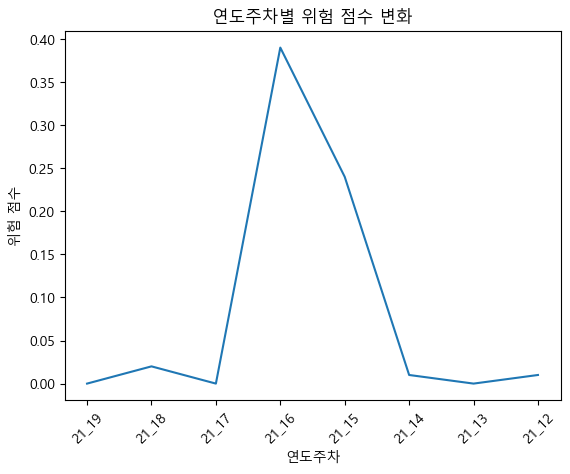

HS Code : 2701129010
21_25주차
21_24주차
21_23주차
21_22주차
21_21주차
21_20주차
21_19주차
21_18주차


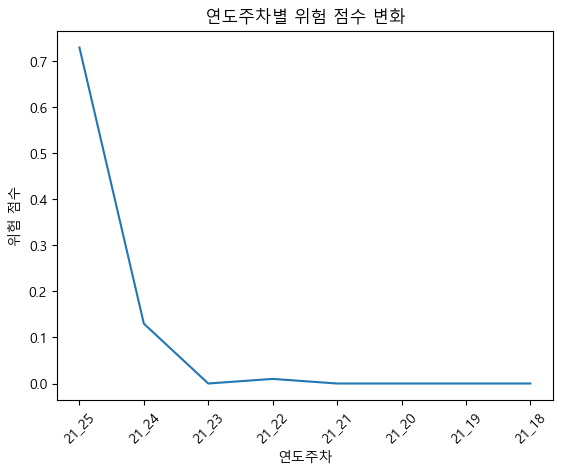

HS Code : 2804701000
21_25주차
21_24주차
21_23주차
21_22주차
21_21주차
21_20주차
21_19주차
21_18주차


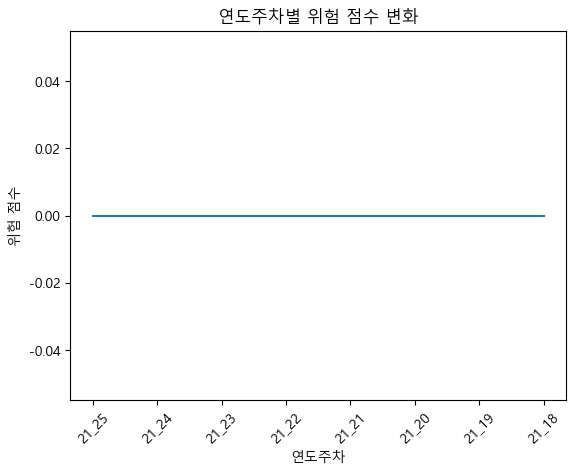

HS Code : 1511901000
21_29주차
21_28주차
21_27주차
21_26주차
21_25주차
21_24주차
21_23주차
21_22주차


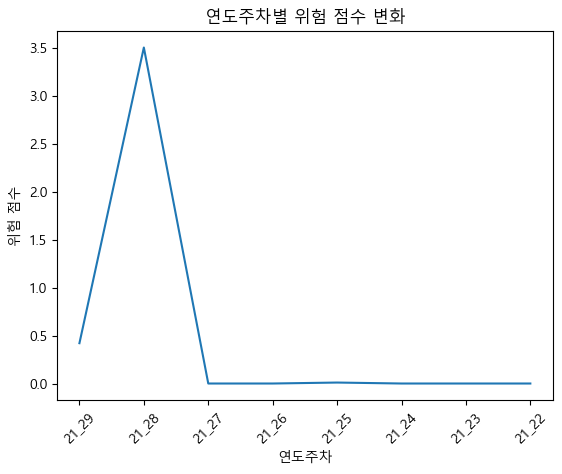

HS Code : 305531000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


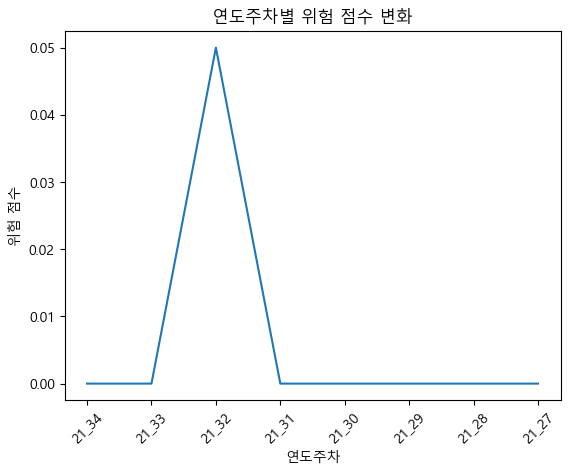

HS Code : 302140000
21_35주차
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차


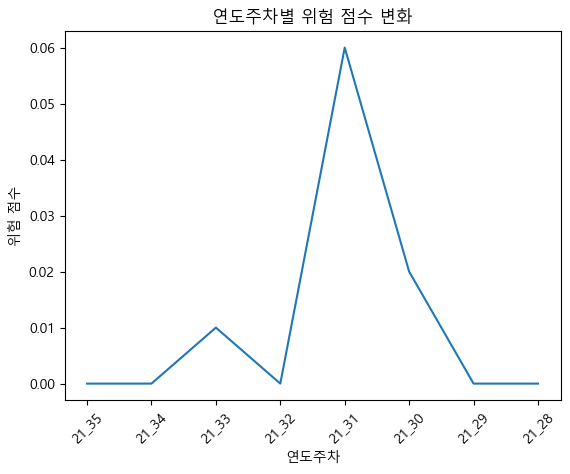

HS Code : 1003901000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


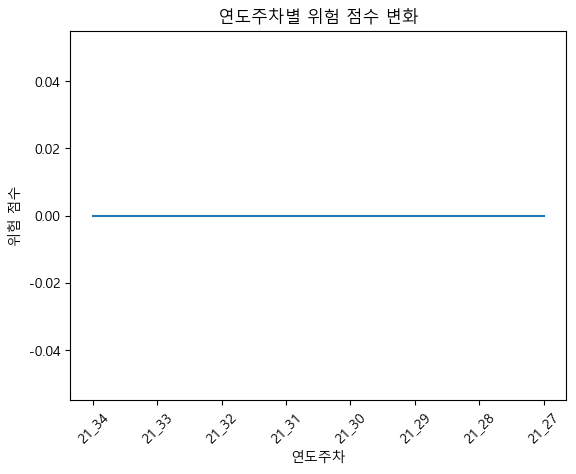

HS Code : 1003902000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


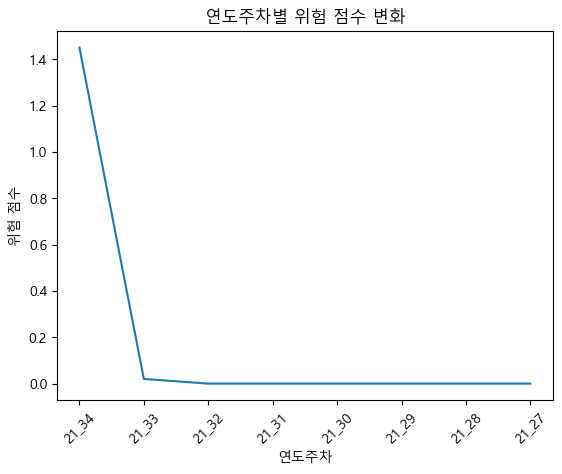

HS Code : 1104230000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


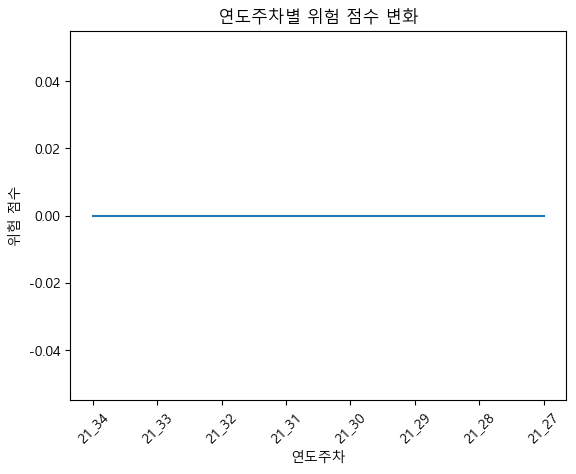

HS Code : 2710121000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


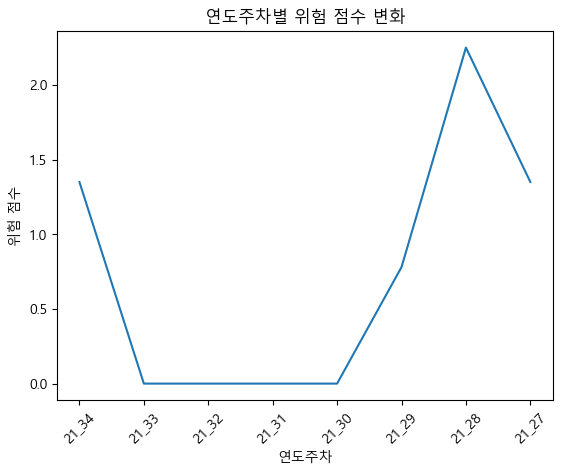

HS Code : 3104200000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


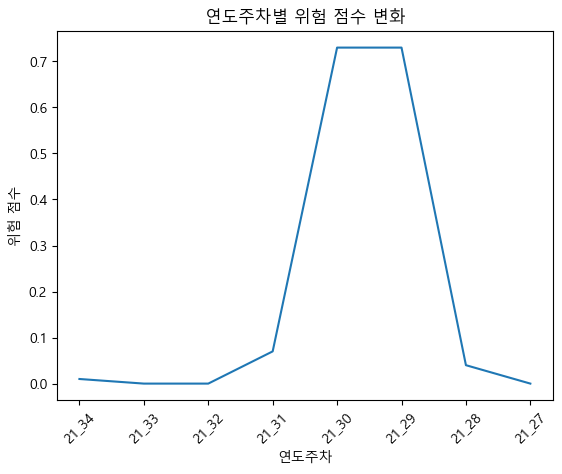

HS Code : 2905172000
21_43주차
21_42주차
21_41주차
21_40주차
21_39주차
21_38주차
21_37주차
21_36주차


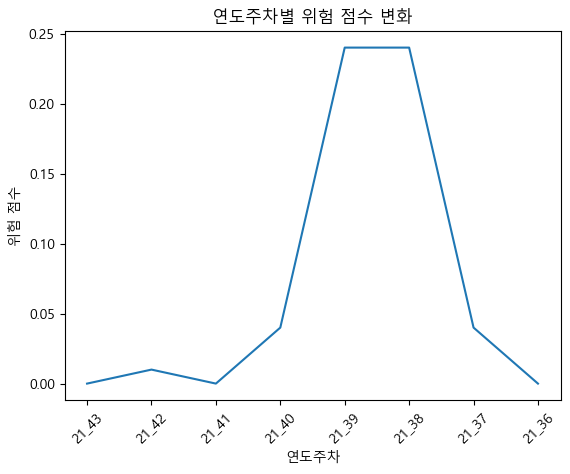

[0, 0, np.float64(0.43), np.float64(0.07), 0, 0, 0, 0, 0, np.float64(0.78), np.float64(0.13), 0, np.float64(3.5), 0, np.float64(0.01), np.float64(0.06), 0, np.float64(2.25), np.float64(1.21), 0, np.float64(0.01), 0, np.float64(3.5), np.float64(0.05), 0, 0, np.float64(1.01), np.float64(0.13), 0, np.float64(0.01), 0, np.float64(1.21), np.float64(0.73), np.float64(0.05), 0, np.float64(3.5), np.float64(0.42), 0, np.float64(0.39), np.float64(0.73), 0, np.float64(3.5), np.float64(0.05), np.float64(0.06), 0, np.float64(1.45), 0, np.float64(2.25), np.float64(0.73), np.float64(0.24)]
[0, 0, 48, 43, 0, 0, 0, 0, 0, 48, 48, 0, 46, 0, 45, 48, 0, 45, 48, 0, 44, 0, 45, 45, 0, 0, 48, 45, 0, 45, 0, 49, 48, 45, 0, 84, 197, 0, 75, 66, 0, 63, 59, 60, 0, 57, 0, 63, 61, 52]


In [33]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        ecdf = ECDF(df_price_4w.iloc[p_eriod-l:-l]['단가'])
        y=np.exp((ecdf(df_price_4w.iloc[-1-l]['단가'])*100 - 95)*np.log(5)/5)

        #=================== 신고중량 percertile 구하기 ====================
        
        ecdf = ECDF(df_price_4w['신고중량'].iloc[p_eriod-l:-l])
        if(ecdf(df_price_4w['신고중량'].iloc[-1-l])>0.5):
            x=np.exp((ecdf(df_price_4w['신고중량'].iloc[-1-l])*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-ecdf(df_price_4w['신고중량'].iloc[-1-l]))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
        
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y      
      
    if(z[j]<1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model0(1)'] = o
collect.loc[50, 'Model0(1)'] = np.sum(o)
collect.loc[:49, 'Model0(2)'] = z
collect.loc[50, 'Model0(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[1]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[1]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[1]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)